# Loading a pretrained model

In [19]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import random
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [27]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [20]:
root_dir = '/content/gtsrb_path'  # Replace with the actual path to your GTSRB dataset

In [21]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),  # Resize images to 32x32
    transforms.ToTensor(),  # Convert PIL images to tensors
    transforms.Normalize((0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669))  # Normalize the image
])

train_dataset = torchvision.datasets.GTSRB(root=root_dir, split="train", transform=transform, download=True)
test_dataset = torchvision.datasets.GTSRB(root=root_dir, split="test", transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

In [22]:
!git clone https://github.com/poojahira/gtsrb-pytorch.git
%cd gtsrb-pytorch


Cloning into 'gtsrb-pytorch'...
remote: Enumerating objects: 23, done.
remote: Total 23 (delta 0), reused 0 (delta 0), pack-reused 23 (from 1)
Receiving objects: 100% (23/23), 3.08 MiB | 20.24 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/gtsrb-pytorch


In [23]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [24]:
from model import Net

model = Net()
model.load_state_dict(torch.load('model/model_40.pth', map_location=device))
model = model.to(device)
model.eval()



Net(
  (conv1): Conv2d(3, 100, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(100, 150, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(150, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(150, 250, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(250, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_drop): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=1000, out_features=350, bias=True)
  (fc2): Linear(in_features=350, out_features=43, bias=True)
  (localization): Sequential(
    (0): Conv2d(3, 8, kernel_size=(7, 7), stride=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(8, 10, kernel_size=(5, 5), stride=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU(inplace=True

In [25]:
def evaluate_model(model, dataloader, device):
    correct = 0
    total = 0
    model.eval()

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Test Accuracy: {100 * correct / total:.2f}%')

In [28]:
evaluate_model(model, test_loader, device)

Test Accuracy: 99.71%


<Figure size 2000x2000 with 0 Axes>

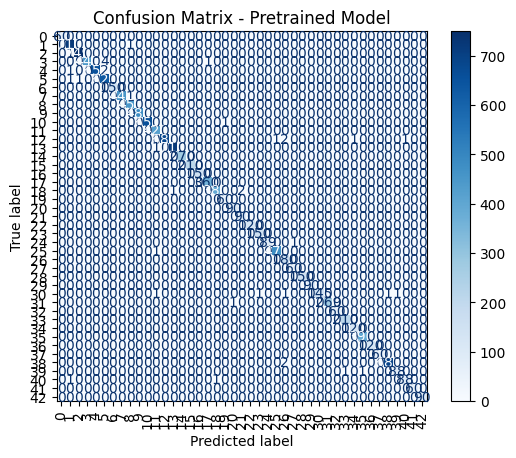

In [32]:
#printing confusion matrix
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

all_preds = []
all_labels = []

# No gradient calculation needed during inference
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(20, 20))
plt.tight_layout()
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix - Pretrained Model")
plt.show()

## Testing on stock images

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
stock_image_dir = "/content/drive/MyDrive/Test_new (1)"
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import os

class SortedImageFolder(ImageFolder):
    def find_classes(self, directory):
        # override to sort folder names numerically
        classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
        classes = sorted(classes, key=lambda x: int(x))  # numeric sort
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx
transform = transforms.Compose([
    transforms.Resize((32, 32)),  # Must match the model input size
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669))  # GTSRB normalization
])
stock_dataset = SortedImageFolder(root=stock_image_dir, transform=transform)
#print(stock_dataset.class_to_idx)
stock_loader = DataLoader(stock_dataset, batch_size=64, shuffle=False)

In [ ]:
evaluate_model(model, stock_loader, device)

Test Accuracy: 79.07%


In [ ]:
print(stock_dataset.class_to_idx)


{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, '21': 21, '22': 22, '23': 23, '24': 24, '25': 25, '26': 26, '27': 27, '28': 28, '29': 29, '30': 30, '31': 31, '32': 32, '33': 33, '34': 34, '35': 35, '36': 36, '37': 37, '38': 38, '39': 39, '40': 40, '41': 41, '42': 42}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.3403, 0.3121, 0.3214])
    std = np.array([0.2724, 0.2608, 0.2669])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

for i in range(5):
    img, label = stock_dataset[i]
    print("Label:", label)
    imshow(img)

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Step 1: Run the model on the stock dataset
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in stock_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
# Step 2: Compute and plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Stock Dataset')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3 conv CNN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

import random
from PIL import Image


In [2]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669))
])

# Download and load training data
train_data = torchvision.datasets.GTSRB(root='/content/gtsrb_path', split='train', transform=transform, download=True)
test_data = torchvision.datasets.GTSRB(root='/content/gtsrb_path', split='test', transform=transform, download=True)

# Data loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


100%|██████████| 187M/187M [00:06<00:00, 27.0MB/s]
100%|██████████| 89.0M/89.0M [00:03<00:00, 28.7MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 307kB/s]


In [3]:
#original
class TrafficSignCNN(nn.Module):
    def __init__(self):
        super(TrafficSignCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*6*6, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 43)  # 43 output classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model
vanilla_model = TrafficSignCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vanilla_model.to(device)


TrafficSignCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=43, bias=True)
  )
)

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vanilla_model.parameters(), lr=0.001)

Epoch 1/60, Loss: 1.2251
Epoch 2/60, Loss: 0.1332
Epoch 3/60, Loss: 0.0599
Epoch 4/60, Loss: 0.0414
Epoch 5/60, Loss: 0.0309
Epoch 6/60, Loss: 0.0342
Epoch 7/60, Loss: 0.0261
Epoch 8/60, Loss: 0.0244
Epoch 9/60, Loss: 0.0208
Epoch 10/60, Loss: 0.0247
Epoch 11/60, Loss: 0.0220
Epoch 12/60, Loss: 0.0195
Epoch 13/60, Loss: 0.0195
Epoch 14/60, Loss: 0.0193
Epoch 15/60, Loss: 0.0128
Epoch 16/60, Loss: 0.0105
Epoch 17/60, Loss: 0.0212
Epoch 18/60, Loss: 0.0136
Epoch 19/60, Loss: 0.0179
Epoch 20/60, Loss: 0.0228
Epoch 21/60, Loss: 0.0174
Epoch 22/60, Loss: 0.0247
Epoch 23/60, Loss: 0.0194
Epoch 24/60, Loss: 0.0118
Epoch 25/60, Loss: 0.0133
Epoch 26/60, Loss: 0.0101
Epoch 27/60, Loss: 0.0121
Epoch 28/60, Loss: 0.0197
Epoch 29/60, Loss: 0.0142
Epoch 30/60, Loss: 0.0182
Epoch 31/60, Loss: 0.0105
Epoch 32/60, Loss: 0.0099
Epoch 33/60, Loss: 0.0150
Epoch 34/60, Loss: 0.0109
Epoch 35/60, Loss: 0.0257
Epoch 36/60, Loss: 0.0078
Epoch 37/60, Loss: 0.0105
Epoch 38/60, Loss: 0.0125
Epoch 39/60, Loss: 0.

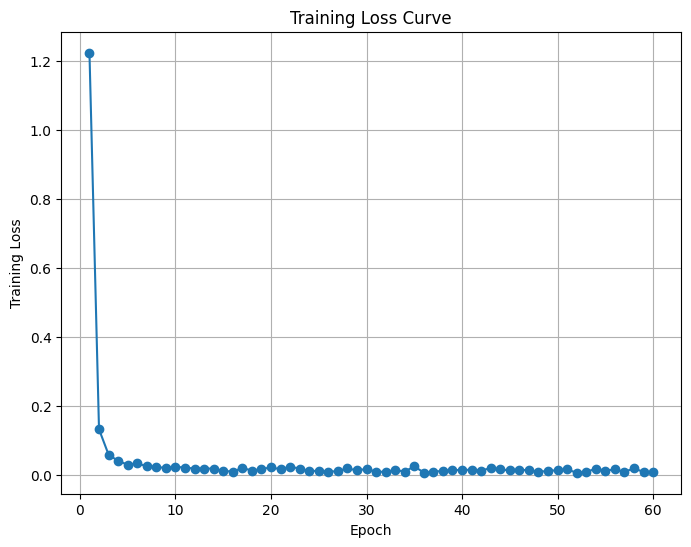

In [6]:
import matplotlib.pyplot as plt

epochs = 60
train_losses = []

for epoch in range(epochs):
    vanilla_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vanilla_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

# Plotting the loss curve
plt.figure(figsize=(8,6))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

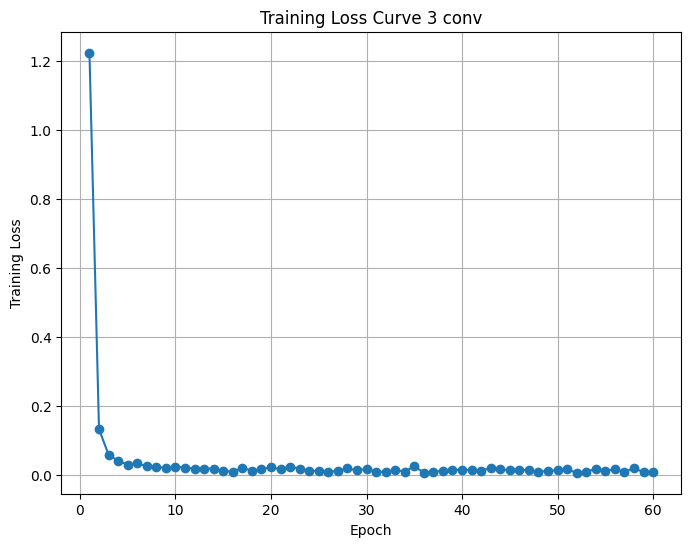

In [9]:
# Plotting the loss curve with updated title
plt.figure(figsize=(8,6))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve 3 conv')
plt.grid(True)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
save_path = '/content/drive/MyDrive/gtsrb_3conv.pth'
torch.save(vanilla_model.state_dict(), save_path)

In [ ]:
model = TrafficSignCNN()
model.load_state_dict(torch.load('/content/drive/MyDrive/gtsrb_3conv.pth', map_location=device))
model = model.to(device)
model.eval()

TrafficSignCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=43, bias=T

In [ ]:
def eval_model_vanilla(model, test_set, device):

  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in test_set:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  print(f"Test Accuracy: {100 * correct / total:.2f}%")

In [ ]:
eval_model_vanilla(model, test_loader, device)  # important for evaluation/inference

Test Accuracy: 94.38%


## Testing on stock images

In [ ]:
stock_image_dir = "/content/drive/MyDrive/Test_new"
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import os

class SortedImageFolder(ImageFolder):
    def find_classes(self, directory):
        # override to sort folder names numerically
        classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
        classes = sorted(classes, key=lambda x: int(x))  # numeric sort
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx

transform = transforms.Compose([
    transforms.Resize((48,48)),  # Must match the model input size
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669))  # GTSRB normalization
])

stock_dataset = SortedImageFolder(root=stock_image_dir, transform=transform)
#print(stock_dataset.class_to_idx)
stock_loader = DataLoader(stock_dataset, batch_size=64, shuffle=False)

In [ ]:
eval_model_vanilla(saved_model, stock_loader, device)  # important for evaluation/inference

Test Accuracy: 54.65%


# 4 conv CNN

In [7]:
#4 conv layers
class TrafficSignCNNNew(nn.Module):
    def __init__(self):
        super(TrafficSignCNNNew, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*3*3, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 43)  # 43 output classes
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model
vanilla_model = TrafficSignCNNNew()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vanilla_model.to(device)


TrafficSignCNNNew(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=43, bia

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vanilla_model.parameters(), lr=0.001)

Epoch 1/60, Loss: 2.1014
Epoch 2/60, Loss: 0.3568
Epoch 3/60, Loss: 0.0872
Epoch 4/60, Loss: 0.0498
Epoch 5/60, Loss: 0.0405
Epoch 6/60, Loss: 0.0298
Epoch 7/60, Loss: 0.0329
Epoch 8/60, Loss: 0.0187
Epoch 9/60, Loss: 0.0209
Epoch 10/60, Loss: 0.0249
Epoch 11/60, Loss: 0.0198
Epoch 12/60, Loss: 0.0231
Epoch 13/60, Loss: 0.0315
Epoch 14/60, Loss: 0.0249
Epoch 15/60, Loss: 0.0214
Epoch 16/60, Loss: 0.0210
Epoch 17/60, Loss: 0.0175
Epoch 18/60, Loss: 0.0251
Epoch 19/60, Loss: 0.0197
Epoch 20/60, Loss: 0.0172
Epoch 21/60, Loss: 0.0100
Epoch 22/60, Loss: 0.0283
Epoch 23/60, Loss: 0.0316
Epoch 24/60, Loss: 0.0141
Epoch 25/60, Loss: 0.0154
Epoch 26/60, Loss: 0.0084
Epoch 27/60, Loss: 0.0314
Epoch 28/60, Loss: 0.0256
Epoch 29/60, Loss: 0.0214
Epoch 30/60, Loss: 0.0142
Epoch 31/60, Loss: 0.0337
Epoch 32/60, Loss: 0.0209
Epoch 33/60, Loss: 0.0255
Epoch 34/60, Loss: 0.0209
Epoch 35/60, Loss: 0.0266
Epoch 36/60, Loss: 0.0209
Epoch 37/60, Loss: 0.0115
Epoch 38/60, Loss: 0.0369
Epoch 39/60, Loss: 0.

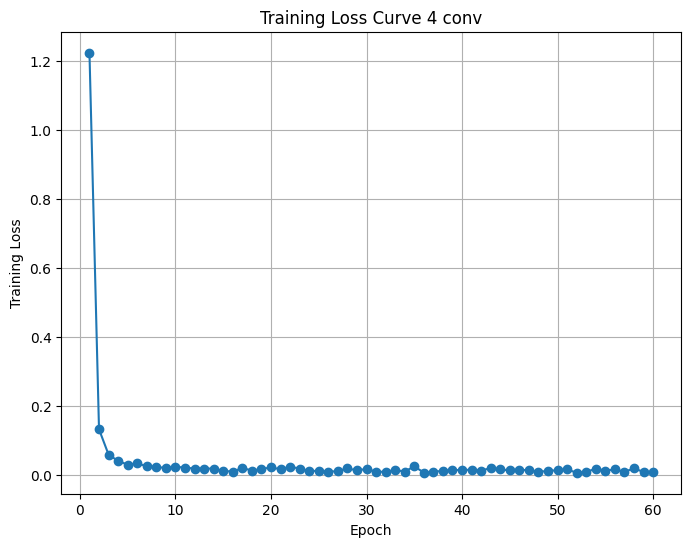

In [10]:
import matplotlib.pyplot as plt

epochs = 60
train_losses_4conv = []

for epoch in range(epochs):
    vanilla_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vanilla_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses_4conv.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

# Plotting the loss curve
plt.figure(figsize=(8,6))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve 4 conv')
plt.grid(True)
plt.show()


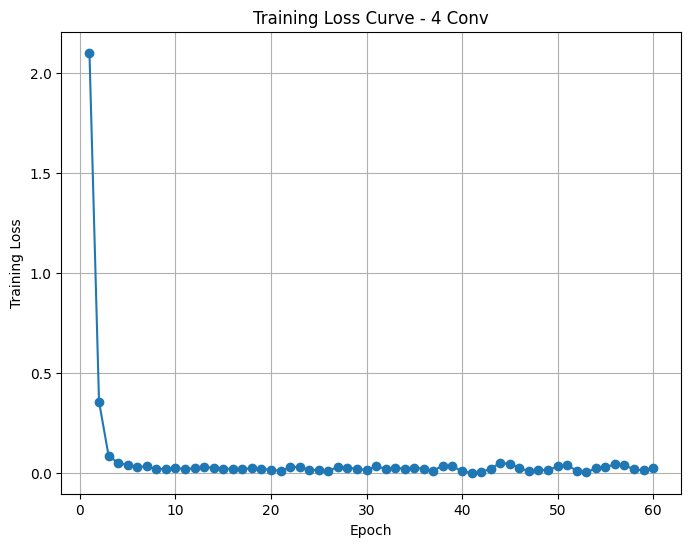

In [16]:
plt.figure(figsize=(8,6))
plt.plot(range(1, len(train_losses_4conv)+1), train_losses_4conv, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve - 4 Conv')
plt.grid(True)
plt.show()


In [ ]:
save_path = '/content/drive/MyDrive/gtsrb_4conv.pth'
torch.save(vanilla_model.state_dict(), save_path)

In [ ]:
model = TrafficSignCNNNew()
model.load_state_dict(torch.load('/content/drive/MyDrive/gtsrb_4conv.pth', map_location=device))
model = model.to(device)
model.eval()

TrafficSignCNNNew(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=43, bia

In [ ]:
eval_model_vanilla(model, test_loader, device)  # important for evaluation/inference

Test Accuracy: 94.75%


In [ ]:
#test on stock data
eval_model_vanilla(model, stock_loader, device)  # important for evaluation/inference

Test Accuracy: 66.28%


# VGG-Style CNN

In [11]:
import torch
import torch.nn as nn

class VGGStyleCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(VGGStyleCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: (48x48) -> (24x24)
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # 48x48
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # 48x48
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # 24x24

            # Block 2: (24x24) -> (12x12)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # 12x12

            # Block 3: (12x12) -> (6x6)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # 6x6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
# Initialize model
vanilla_model = VGGStyleCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vanilla_model.to(device)

VGGStyleCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vanilla_model.parameters(), lr=0.001)

Epoch 1/30, Loss: 0.5048
Epoch 2/30, Loss: 0.1002
Epoch 3/30, Loss: 0.0623
Epoch 4/30, Loss: 0.0377
Epoch 5/30, Loss: 0.0430
Epoch 6/30, Loss: 0.0347
Epoch 7/30, Loss: 0.0244
Epoch 8/30, Loss: 0.0314
Epoch 9/30, Loss: 0.0316
Epoch 10/30, Loss: 0.0184
Epoch 11/30, Loss: 0.0219
Epoch 12/30, Loss: 0.0290
Epoch 13/30, Loss: 0.0183
Epoch 14/30, Loss: 0.0255
Epoch 15/30, Loss: 0.0211
Epoch 16/30, Loss: 0.0226
Epoch 17/30, Loss: 0.0115
Epoch 18/30, Loss: 0.0259
Epoch 19/30, Loss: 0.0460
Epoch 20/30, Loss: 0.0165
Epoch 21/30, Loss: 0.0117
Epoch 22/30, Loss: 0.0023
Epoch 23/30, Loss: 0.0081
Epoch 24/30, Loss: 0.0438
Epoch 25/30, Loss: 0.0194
Epoch 26/30, Loss: 0.0169
Epoch 27/30, Loss: 0.0081
Epoch 28/30, Loss: 0.0118
Epoch 29/30, Loss: 0.0193
Epoch 30/30, Loss: 0.0254


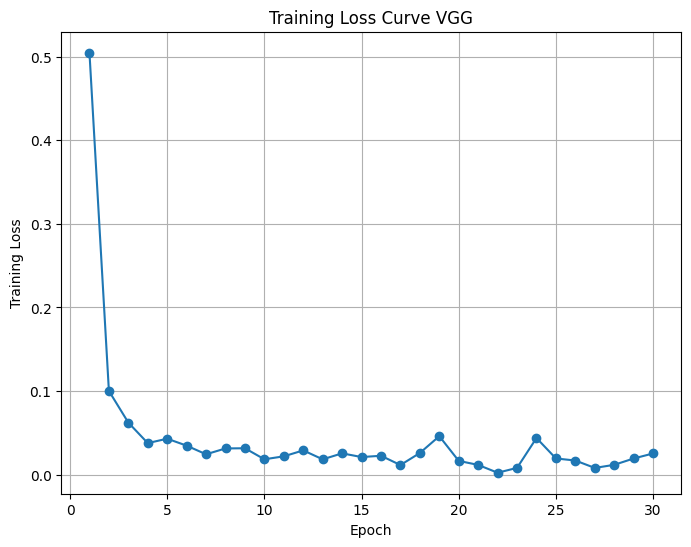

In [17]:
import matplotlib.pyplot as plt

epochs = 30
train_losses_vgg = []

for epoch in range(epochs):
    vanilla_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vanilla_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses_vgg.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

# Plotting the loss curve
plt.figure(figsize=(8,6))
plt.plot(range(1, epochs+1), train_losses_vgg, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve VGG')
plt.grid(True)
plt.show()

In [ ]:
save_path = '/content/drive/MyDrive/gtsrb_vgg_model.pth'
torch.save(vanilla_model.state_dict(), save_path)

In [ ]:
model = VGGStyleCNN()
model.load_state_dict(torch.load('/content/drive/MyDrive/gtsrb_vgg_model.pth', map_location=device))
model = model.to(device)
model.eval()

VGGStyleCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1

In [ ]:
eval_model_vanilla(model, test_loader, device)  # important for evaluation/inference

Test Accuracy: 96.13%


In [ ]:
#test on stock data
eval_model_vanilla(model, stock_loader, device)  # important for evaluation/inference

Test Accuracy: 56.98%


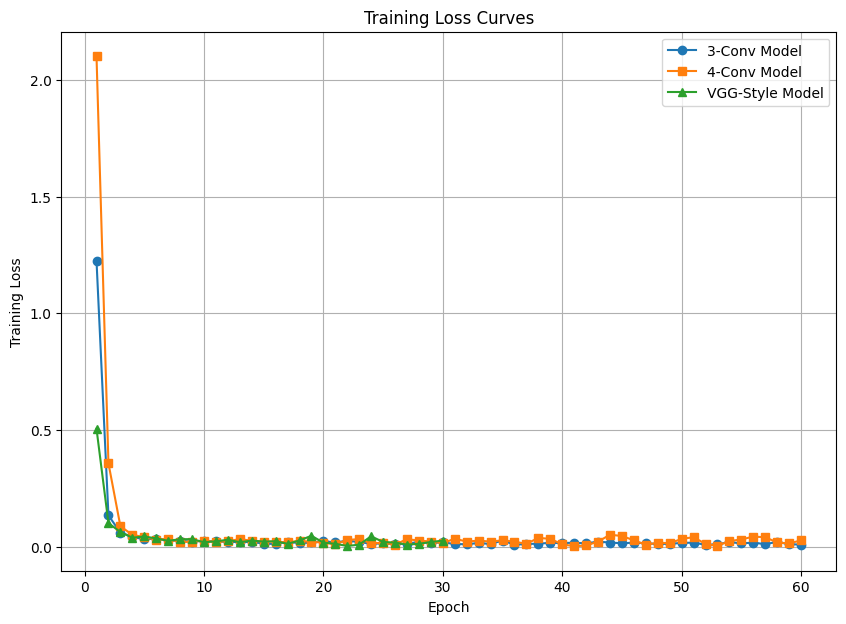

In [18]:
#plotting all loss curves on the same plot
epochs = max(len(train_losses), len(train_losses_4conv), len(train_losses_vgg))
epoch_range = range(1, epochs + 1)

# Plotting
plt.figure(figsize=(10, 7))

# Plot each curve (adjust if lengths differ)
if len(train_losses) == epochs:
    plt.plot(epoch_range, train_losses, label='3-Conv Model', marker='o')
else:
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='3-Conv Model', marker='o')

if len(train_losses_4conv) == epochs:
    plt.plot(epoch_range, train_losses_4conv, label='4-Conv Model', marker='s')
else:
    plt.plot(range(1, len(train_losses_4conv) + 1), train_losses_4conv, label='4-Conv Model', marker='s')

if len(train_losses_vgg) == epochs:
    plt.plot(epoch_range, train_losses_vgg, label='VGG-Style Model', marker='^')
else:
    plt.plot(range(1, len(train_losses_vgg) + 1), train_losses_vgg, label='VGG-Style Model', marker='^')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

# Using LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c9db4b84d062cdb69dde854d8860f777eecc305578fbbb19fb4da542ff07a60f
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


  0%|          | 0/1000 [00:00<?, ?it/s]

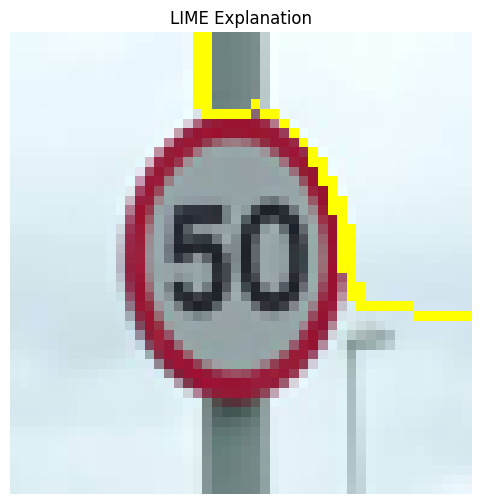

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# 1. Load your trained VGG-style CNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VGGStyleCNN()
model.load_state_dict(torch.load("/content/drive/MyDrive/gtsrb_vgg_model.pth", map_location=device))  # adjust path
model.to(device)
model.eval()

# 2. Define prediction function for LIME
def predict_fn(images_np):
    """
    Takes a list of images in NumPy format (H, W, C), normalized [0, 255]
    Returns class probabilities from the model.
    """
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # adjust if different
    ])

    images_tensor = torch.stack([transform(Image.fromarray(img.astype('uint8'))) for img in images_np])
    images_tensor = images_tensor.to(device)

    with torch.no_grad():
        outputs = model(images_tensor)
        probs = F.softmax(outputs, dim=1)

    return probs.cpu().numpy()

# 3. Load image to explain
image_path = "/content/image4.jpeg"  # replace with your image path
original_img = Image.open(image_path).convert("RGB")
original_img = original_img.resize((48, 48))
image_np = np.array(original_img)

# 4. LIME Explainer
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image_np,
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000  # more samples = better explanation
)

# 5. Visualize Explanation
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=False,
    num_features=10,
    min_weight=0.0
)

plt.figure(figsize=(6, 6))
plt.title("LIME Explanation")
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.axis("off")
plt.show()
